# 00 — Hardware Definition

> **Required starting point for every cooldown and experiment campaign.**

## Purpose

Initialize the sample identity, cooldown context, and hardware session that all subsequent notebooks depend on. This notebook establishes the single source of truth for port bindings, LO/IF frequencies, ADC offsets, external LO routing, and device definitions.

## Methodology

1. **Analysis sanity check** — verify `qubox_tools` imports cleanly and fits execute correctly
2. **Hardware runtime imports** — load the notebook API surface (`qubox.notebook`)
3. **Sample & cooldown registration** — create or reuse the sample and cooldown directory tree
4. **Explicit hardware definition** — define element bindings, LO frequencies, aliases, ADC offsets, external devices
5. **Session open** — connect to the OPX+ via the hosted QM server and persist bootstrap metadata
6. **Preflight snapshot** — validate the config directory, save a reproducible session state hash

## Expected Outcomes

- A live `session` object connected to the Quantum Machines hardware
- Bootstrap metadata persisted to disk for reuse by later notebooks
- All preflight checks passing (schema validation, config integrity)
- Runtime frequency targets and thermalization waits displayed

## Prerequisites

None — this is the first notebook in the sequence.

## Notebook Sequence

| # | Notebook | Purpose |
|---|----------|---------|
| **00** | **`00_hardware_defintion`** | **Sample, cooldown, runtime, and reference sanity checks** |
| 01 | `01_mixer_calibrations` | Automatic and manual mixer calibration |
| 02 | `02_time_of_flight` | Raw ADC readout trace and arrival timing |
| 03 | `03_resonator_spectroscopy` | 1D resonator frequency fit |
| 04 | `04_resonator_power_chevron` | 2D readout power/frequency refinement |
| 05 | `05_qubit_spectroscopy_pulse_calibration` | Qubit spectroscopy, pulse seeding, Rabi diagnostics |
| 06 | `06_coherence_experiments` | T1, Ramsey, and Echo validation |

## 0. Analysis Sanity Check

Validate that `qubox_tools` imports cleanly and that basic fitting works before attempting any hardware-facing runtime imports. A failure here indicates an environment issue (wrong Python version, missing packages).

In [26]:
import sys
import numpy as np

sys.path.insert(0, r"E:\qubox")

import qubox_tools as qt

x = np.linspace(-1.0, 1.0, 41)
y = qt.fitting.models.gaussian_model(x, 0.15, 0.2, 0.8, 0.1)
popt, _ = qt.generalized_fit(
    x,
    y,
    qt.fitting.models.gaussian_model,
    p0=[0.0, 0.25, 1.0, 0.0],
)
print("qubox_tools sanity fit:", np.round(popt, 4))

qubox_tools sanity fit: [0.15 0.2  0.8  0.1 ]


## 1. Hardware Runtime Imports

All remaining cells require the lab runtime stack, including qualang_tools, qm, and access to the configured Quantum Machines environment.

In [16]:
import sys

sys.path.insert(0, r"E:\qubox")

from pathlib import Path
from qualang_tools.units import unit

from qubox.notebook import ArtifactManager
from qubox.notebook import CalibrationOrchestrator
from qubox.notebook import SampleRegistry
from qubox.notebook import SessionState
from qubox.notebook import get_notebook_session_bootstrap_path
from qubox.notebook import get_shared_session
from qubox.notebook import open_shared_session
from qubox.notebook import preflight_check
from qubox.notebook import save_config_snapshot
from qubox.notebook import validate_config_dir

u = unit()

## 2. Sample Registry and Cooldown Setup

Create or reuse the sample entry, then create or reuse the cooldown directory for the current run.

In [17]:
REGISTRY_BASE = Path(r"E:\qubox")

registry = SampleRegistry(REGISTRY_BASE)
print(f"Registry base: {registry.base_path}")
print(f"Existing samples: {registry.list_samples()}")

SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"

if not registry.sample_exists(SAMPLE_ID):
    sample_path = registry.create_sample(
        SAMPLE_ID,
        description="Transmon qubit A - 3D cavity sample",
        config_source=Path(r"E:\qubox\seq_1_device\config"),
        metadata={"chip": "Q1-2025A", "fridge": "BlueFors-LD400"},
    )
    print(f"Created sample at: {sample_path}")
else:
    print(f"Sample '{SAMPLE_ID}' already exists")

info = registry.load_sample_info(SAMPLE_ID)
print(f"Sample: {info.sample_id} - {info.description}")

if not registry.cooldown_exists(SAMPLE_ID, COOLDOWN_ID):
    cooldown_path = registry.create_cooldown(
        SAMPLE_ID,
        COOLDOWN_ID,
        seed_from=Path(r"E:\qubox\seq_1_device\config"),
    )
    print(f"Created cooldown at: {cooldown_path}")
else:
    print(f"Cooldown '{COOLDOWN_ID}' already exists")

print(f"Cooldowns for {SAMPLE_ID}: {registry.list_cooldowns(SAMPLE_ID)}")

Registry base: E:\qubox
Existing samples: ['post_cavity_sample_A']
Sample 'post_cavity_sample_A' already exists
Sample: post_cavity_sample_A - Transmon qubit A — 3D cavity sample
Created cooldown at: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24
Cooldowns for post_cavity_sample_A: ['cd_2025_02_22', 'cd_2026_03_02', 'cd_2026_03_24']


## 2.1 Explicit Hardware Definition

Edit the dictionaries in the next cell to define the sample-level hardware explicitly before opening the session.
This section is the source of truth for port bindings, LO and IF values, aliases, ADC offsets, external LO routing, and external device definitions.

Leave `WRITE_SAMPLE_HARDWARE_DEFINITION = False` while reviewing the preview. Set it to `True` only when you want to write the sample-level `hardware.json` and `devices.json`.

In [19]:
import json

from qubox.notebook import HardwareDefinition

WRITE_SAMPLE_HARDWARE_DEFINITION = True

HARDWARE_CONTROLLER = "con1"
HARDWARE_OCTAVE = "oct1"

# These default mixer gains target about -30 dBm CW power in notebook 01 auto SA validation,
# except resonator which is intentionally kept near -40 dBm.
READOUT_ELEMENTS = {
    "resonator": {
        "rf_out": 1,
        "rf_in": 1,
        "lo_frequency": 8.8e9,
        "frequency": 8.75e9,
        "intermediate_frequency": -50e6,
        "gain": -10.0,
        "time_of_flight": 280,
        "digital_inputs": {
            "switch": (1, 0, 0),
            "pump": (2, 114, 18),
        },
        "lo_source": "internal",
    },
}

CONTROL_ELEMENTS = {
    "transmon": {
        "rf_out": 3,
        "lo_frequency": 6.2e9,
        "frequency": 6.15e9,
        "intermediate_frequency": -50e6,
        "gain": 3.0,
        "digital_inputs": {
            "switch": (3, 57, 18),
        },
        "lo_source": "internal",
    },
    "storage": {
        "rf_out": 5,
        "lo_frequency": 5.4e9,
        "frequency": 5.35e9,
        "intermediate_frequency": -50e6,
        "gain": 0.0,
        "digital_inputs": {
            "switch": (5, 57, 18),
        },
        "lo_source": "internal",
    },
    "storage_gf": {
        "rf_out": 4,
        "intermediate_frequency": -50e6,
        "gain": 6.5,
        "digital_inputs": {
            "switch": (2, 57, 18),
        },
        "lo_frequency": 7.0e9,
        "lo_source": "external",
    },
    "resonator_gf": {
        "rf_out": 2,
        "intermediate_frequency": -50e6,
        "gain": 7.5,
        "digital_inputs": {
            "switch": (2, 57, 18),
        },
        "lo_frequency": 3.5e9,
        "lo_source": "external",
    },
}

ALIASES = {
    "qubit": "transmon",
    "readout": "resonator",
    "storage": "storage",
}

ADC_OFFSETS = {
    1: 0.00947713,
    2: 0.00962465,
}

INSTRUMENT_SERVER = {
    "host": "10.157.36.75",
    "port": 50183,
    "timeout": 60000,
}

EXTERNAL_DEVICES = {
    "octave_external_lo2": {
        "instrument_name": "sc_34F3",
        "settings": {
            "frequency": 3.5e9,
            "power": 8.5,
            "output_status": True,
        },
    },
    "octave_external_lo4": {
        "instrument_name": "sc_38B5",
        "settings": {
            "frequency": 7.0e9,
            "power": 10.0,
            "output_status": True,
        },
    },
    "octodac_bf": {
        "instrument_name": "octodac_bf",
        "settings": {},
    },
    "sa124b": {
        "instrument_name": "sa124b_20234880",
        "settings": {},
    },
}

EXTERNAL_LO_BINDINGS = {
    2: {"device": "octave_external_lo2", "lo_port": "LO2"},
    4: {"device": "octave_external_lo4", "lo_port": "LO4"},
}

sample_level_config_dir = registry.sample_path(SAMPLE_ID) / "config"
sample_hardware_path = sample_level_config_dir / "hardware.json"
sample_devices_path = sample_level_config_dir / "devices.json"

hardware_definition = HardwareDefinition(
    controller=HARDWARE_CONTROLLER,
    octave=HARDWARE_OCTAVE,
)

for element_name, spec in READOUT_ELEMENTS.items():
    hardware_definition.add_readout(element_name, **spec)

for element_name, spec in CONTROL_ELEMENTS.items():
    hardware_definition.add_control(element_name, **spec)

if ALIASES:
    hardware_definition.set_aliases(ALIASES)

if ADC_OFFSETS:
    hardware_definition.set_adc_offsets(ADC_OFFSETS)

if INSTRUMENT_SERVER is not None:
    hardware_definition.set_instrument_server(**INSTRUMENT_SERVER)

for device_name, device_spec in EXTERNAL_DEVICES.items():
    hardware_definition.add_device(device_name, **device_spec)

for rf_out, lo_spec in EXTERNAL_LO_BINDINGS.items():
    hardware_definition.set_external_lo(
        int(rf_out),
        device=lo_spec["device"],
        lo_port=lo_spec["lo_port"],
    )

hardware_preview = hardware_definition.to_hardware_dict()
preview_payload = {
    "hardware_path": str(sample_hardware_path),
    "devices_path": str(sample_devices_path),
    "elements": list(hardware_preview["elements"].keys()),
    "aliases": hardware_preview.get("__qubox", {}).get("aliases", {}),
    "bindings": hardware_preview.get("__qubox", {}).get("bindings", {}),
    "external_lo_map": hardware_preview.get("__qubox", {}).get("external_lo_map", {}),
    "devices": hardware_definition.to_devices_dict(),
}
print(json.dumps(preview_payload, indent=2))

if WRITE_SAMPLE_HARDWARE_DEFINITION:
    hardware_definition.save_hardware(sample_hardware_path)
    devices_written = hardware_definition.save_devices(sample_devices_path, merge_existing=True)
    print("\nPersisted sample-level hardware definition.")
    print(f"hardware.json    -> {sample_hardware_path}")
    if devices_written is not None:
        print(f"devices.json     -> {devices_written}")
    else:
        print("devices.json     -> not written (no external devices defined)")
else:
    print(
        "\nPreview only. Edit the dictionaries above, set WRITE_SAMPLE_HARDWARE_DEFINITION = True, "
        "and rerun this cell before opening the session."
    )

{
  "hardware_path": "E:\\qubox\\samples\\post_cavity_sample_A\\config\\hardware.json",
  "devices_path": "E:\\qubox\\samples\\post_cavity_sample_A\\config\\devices.json",
  "elements": [
    "resonator",
    "transmon",
    "storage",
    "storage_gf",
    "resonator_gf"
  ],
  "aliases": {
    "resonator": "oct1:RF_out:1",
    "transmon": "oct1:RF_out:3",
    "storage": "oct1:RF_out:5",
    "storage_gf": "oct1:RF_out:4",
    "resonator_gf": "oct1:RF_out:2"
  },
  "bindings": {
    "outputs": {
      "resonator": {
        "channel": [
          "oct1",
          "RF_out",
          1
        ],
        "intermediate_frequency": -50000000.0,
        "lo_frequency": 8800000000.0,
        "gain": -10.0,
        "digital_inputs": {
          "switch": [
            "con1",
            "digital_out",
            1
          ],
          "pump": [
            "con1",
            "digital_out",
            2
          ]
        },
        "operations": {
          "const": "const_pulse",
  

## 3. Session Open and Context Verification

Open the shared session for this cooldown and persist the bootstrap metadata used by later notebooks.
If notebook 01 or later is attached to the same kernel, it can reuse this live session directly.
If a later notebook starts in a fresh kernel, it can reopen the same sample and cooldown session from the saved bootstrap file with a single helper call.

If the hardware definition changed since the last cooldown calibration was written, the next cell backs up the stale `calibration.json`, regenerates a fresh calibration store for the new wiring revision, and then opens the session.

In [20]:
import shutil
from datetime import datetime

from qubox.notebook import ContextMismatchError

SESSION_BOOTSTRAP_PATH = get_notebook_session_bootstrap_path(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,)

existing_session = get_shared_session()
open_session_kwargs = dict(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
    auto_save_calibration=True,
)

recovered_from_context_mismatch = False
calibration_backup_path = None

try:
    session = open_shared_session(**open_session_kwargs)
except ContextMismatchError as exc:
    if "Wiring revision mismatch" not in str(exc):
        raise

    cooldown_config_dir = registry.cooldown_path(SAMPLE_ID, COOLDOWN_ID) / "config"
    calibration_path = cooldown_config_dir / "calibration.json"

    if calibration_path.exists():
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        calibration_backup_path = calibration_path.with_name(
            f"{calibration_path.stem}_{timestamp}_wiring_mismatch_backup{calibration_path.suffix}"
        )
        shutil.copy2(calibration_path, calibration_backup_path)
        calibration_path.unlink()
        print("Calibration context mismatch detected during session open.")
        print(f"Backed up stale calibration to: {calibration_backup_path}")
        print(
            "Removed the stale cooldown calibration so a fresh store can be created for the current hardware definition."
        )
    else:
        print("Calibration context mismatch detected, but no cooldown calibration.json was found to back up.")

    session = open_shared_session(force_reopen=True, **open_session_kwargs)
    recovered_from_context_mismatch = True

ctx = session.context
print(f"Shared session: {'reused live kernel session' if existing_session is session else 'opened new live session'}")
print(f"Bootstrap path: {SESSION_BOOTSTRAP_PATH}")
print(f"Sample ID:      {ctx.sample_id}")
print(f"Cooldown ID:    {ctx.cooldown_id}")
print(f"Wiring Rev:     {ctx.wiring_rev}")
print(f"Config Hash:    {ctx.config_hash}")
print(f"Schema Version: {ctx.schema_version}")
print(f"Experiment Path: {session.experiment_path}")

if recovered_from_context_mismatch and calibration_backup_path is not None:
    print(f"Recovered by resetting cooldown calibration from backup: {calibration_backup_path.name}")

attr = session.context_snapshot()
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

cal_ctx = session.calibration.data.context
if cal_ctx:
    print(f"\nCalibration bound to sample:   {cal_ctx.sample_id}")
    print(f"Calibration bound to cooldown: {cal_ctx.cooldown_id}")
    print(f"Calibration wiring rev:        {cal_ctx.wiring_rev}")
else:
    print("\nNo context block in calibration yet; it will be stamped on first save.")

orch = CalibrationOrchestrator(session)

# Uncomment to run in simulation mode.
# session.hardware.set_exec_mode("simulate")

2026-03-24 01:36:39,276 - qm - INFO     - Performing health check
2026-03-24 01:36:39,282 - qm - INFO     - Health check passed


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(
No measureConfig.json found — explicit readout config will use defaults. Run readout calibration to populate it.


Shared session: opened new live session
Bootstrap path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_session.json
Sample ID:      post_cavity_sample_A
Cooldown ID:    cd_2026_03_24
Wiring Rev:     addf71a9
Config Hash:    84fa4df461eb
Schema Version: 5.0.0
Experiment Path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24
Resonator: 8.7500 GHz
Qubit:     6.1500 GHz
Storage:   5.3500 GHz

Calibration bound to sample:   post_cavity_sample_A
Calibration bound to cooldown: cd_2026_03_24
Calibration wiring rev:        addf71a9


In [23]:
# ── Set Reference Calibration Values for Fresh Commissioning ─────────────────
#
# These are the known reference frequencies and parameters for this device.
# Setting them in the calibration store so all downstream experiments start
# from a physically correct configuration.

# Reference frequencies (Hz)
session.calibration.set_frequencies(
    "resonator",
    resonator_freq=8596222556.078796,
    kappa=4156000.0,
)
session.calibration.set_frequencies(
    "transmon",
    qubit_freq=6150358764.4830475,
    anharmonicity=-255669694.5244608,
)
session.calibration.set_frequencies(
    "storage",
    storage_freq=5240932800.0,
)

# Storage chi parameters
session.calibration.set_cqed_params(
    "storage",
    st_chi=-2840421.354241756,
    st_chi2=-21912.638362342423,
    st_chi3=-327.37857577643325,
)

# Set thermalization clocks
session.calibration.set_coherence(
    "transmon",
    qb_therm_clks=20000,
)
session.calibration.set_coherence(
    "resonator",
    ro_therm_clks=1000,
)

session.calibration.save()
print("Reference calibration values written to calibration.json")

# Verify the values
attr = session.context_snapshot()
print(f"\nResonator: {attr.ro_fq / 1e9:.6f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.6f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.6f} GHz")
print(f"Anharmonicity: {attr.anharmonicity / 1e6:.2f} MHz")
print(f"qb_therm_clks: {attr.qb_therm_clks}")
print(f"ro_therm_clks: {attr.ro_therm_clks}")

Reference calibration values written to calibration.json

Resonator: 8.596223 GHz
Qubit:     6.150359 GHz
Storage:   5.240933 GHz
Anharmonicity: -255.67 MHz
qb_therm_clks: 20000
ro_therm_clks: 1000


## 4. Preflight Snapshot

Capture a reproducible session snapshot and validate the cooldown configuration directory before continuing.

In [24]:
import shutil

config_dir = Path(session.experiment_path) / "config"
sample_config_dir = getattr(session, "_sample_config_dir", None)
sample_config_dir = Path(sample_config_dir) if sample_config_dir is not None else None

session_state_config_dir = Path(session.experiment_path) / "artifacts" / "_session_state_config"
session_state_config_dir.mkdir(parents=True, exist_ok=True)

for stale_file in session_state_config_dir.glob("*.json"):
    stale_file.unlink()

for source_dir in [sample_config_dir, config_dir]:
    if source_dir is None:
        continue
    for file_name in ("hardware.json", "calibration.json", "pulse_specs.json"):
        src = source_dir / file_name
        if src.exists():
            shutil.copy2(src, session_state_config_dir / file_name)

ss = SessionState.from_config_dir(session_state_config_dir)
am = ArtifactManager(session.experiment_path, ss.build_hash)
am.save_session_state(ss.to_dict())
print(ss.summary())
print(f"\nArtifacts root: {am.root}")

report = preflight_check(session)
if report["all_ok"]:
    print("All preflight checks PASSED.")
else:
    print("PREFLIGHT FAILURES:")
    for err in report["errors"]:
        print(f"  - {err}")

if report["warnings"]:
    print("Warnings:")
    for warning in report["warnings"]:
        print(f"  - {warning}")

snapshot_path = save_config_snapshot(session, tag="session_open")
print(f"\nConfig snapshot saved to: {snapshot_path}")

print("\nSchema validation:")
schema_targets = []
if sample_config_dir is not None:
    schema_targets.append(("sample", sample_config_dir))
schema_targets.append(("cooldown", config_dir))

file_order = [
    "hardware.json",
    "pulse_specs.json",
    "pulses.json",
    "calibration.json",
    "measureConfig.json",
    "devices.json",
]

for scope, target_dir in schema_targets:
    print(f"\n[{scope}] {target_dir}")
    schema_results = validate_config_dir(target_dir)
    if not schema_results:
        print("  No recognized config files found.")
        continue
    existing_files = [name for name in file_order if (target_dir / name).exists()]
    for file_name, result in zip(existing_files, schema_results):
        status = "PASS" if result.valid else "FAIL"
        print(f"  {file_name}: {status} v={result.version}")
        for error in result.errors:
            print(f"    ERROR: {error}")
        for warning in result.warnings:
            print(f"    WARN: {warning}")

SessionState
  config_dir:  E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\_session_state_config
  build_hash:  eade0e402892
  git_commit:  9be7c62
  hardware:    5 elements
  calibration: version=5.1.0
  pulse_specs: (absent)

Artifacts root: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\eade0e402892
All preflight checks PASSED.

Config snapshot saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\config_snapshot_session_open_20260324_013853.json

Schema validation:

[sample] E:\qubox\samples\post_cavity_sample_A\config
  hardware.json: PASS v=1
  devices.json: PASS v=1

[cooldown] E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\config
  calibration.json: PASS v=5.1.0


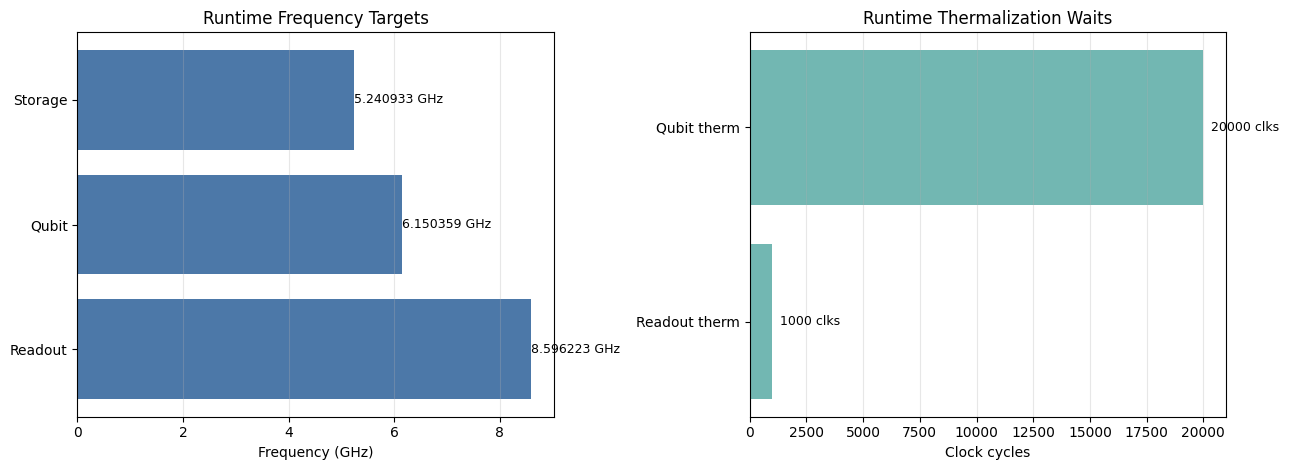

Runtime session values:
  Readout     : 8.596223 GHz
  Qubit       : 6.150359 GHz
  Storage     : 5.240933 GHz
  Readout therm: 1000 clks
  Qubit therm : 20000 clks


In [25]:
import matplotlib.pyplot as plt
import numpy as np

context_snapshot = getattr(session, "context_snapshot", None)
runtime_attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attr", None)
if runtime_attr is None:
    raise RuntimeError("Session attribute bundle is unavailable; rerun the session bootstrap cells above.")


def as_float_or_nan(value):
    return np.nan if value is None else float(value)


freq_rows = [
    ("Readout", as_float_or_nan(getattr(runtime_attr, "ro_fq", np.nan))),
    ("Qubit", as_float_or_nan(getattr(runtime_attr, "qb_fq", np.nan))),
    ("Storage", as_float_or_nan(getattr(runtime_attr, "st_fq", np.nan))),
]
clock_rows = [
    ("Readout therm", as_float_or_nan(getattr(runtime_attr, "ro_therm_clks", 1000))),
    ("Qubit therm", as_float_or_nan(getattr(runtime_attr, "qb_therm_clks", np.nan))),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

freq_positions = np.arange(len(freq_rows))
freq_values_ghz = [value / 1e9 if np.isfinite(value) else 0.0 for _, value in freq_rows]
axes[0].barh(freq_positions, freq_values_ghz, color="#4c78a8")
axes[0].set_yticks(freq_positions)
axes[0].set_yticklabels([label for label, _ in freq_rows])
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_title("Runtime Frequency Targets")
axes[0].grid(axis="x", alpha=0.3)
for idx, (_, value) in enumerate(freq_rows):
    if np.isfinite(value):
        axes[0].text(value / 1e9 + 0.0015, idx, f"{value / 1e9:.6f} GHz", va="center", fontsize=9)
    else:
        axes[0].text(0.0015, idx, "unavailable", va="center", fontsize=9)

clock_positions = np.arange(len(clock_rows))
clock_values = [value if np.isfinite(value) else 0.0 for _, value in clock_rows]
axes[1].barh(clock_positions, clock_values, color="#72b7b2")
axes[1].set_yticks(clock_positions)
axes[1].set_yticklabels([label for label, _ in clock_rows])
axes[1].set_xlabel("Clock cycles")
axes[1].set_title("Runtime Thermalization Waits")
axes[1].grid(axis="x", alpha=0.3)
for idx, (_, value) in enumerate(clock_rows):
    if np.isfinite(value):
        axes[1].text(value + 350, idx, f"{value:.0f} clks", va="center", fontsize=9)
    else:
        axes[1].text(350, idx, "unavailable", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Runtime session values:")
for label, value in freq_rows:
    if np.isfinite(value):
        print(f"  {label:12s}: {value / 1e9:.6f} GHz")
    else:
        print(f"  {label:12s}: unavailable")

for label, value in clock_rows:
    if np.isfinite(value):
        print(f"  {label:12s}: {value:.0f} clks")
    else:
        print(f"  {label:12s}: unavailable")

## 6. Runtime Sanity Plots

Summarize the active runtime attributes from this session before moving on to later experiment notebooks. This is a quick check that the current frequencies and wait times are populated and physically reasonable.